In [1]:
from matplotlib import pyplot as plt
import numpy as np 

import pandas as pd

from pathlib import Path

In [2]:
DATA_DIR = Path("../../artifacts/2023-06-s8/baseline-superclasses/")

In [5]:
def load(
    dataset, 
    model,
    num_samples, 
    seeds=list(range(1, 5+1))
):
    
#     ./artifacts/2023-06-s8/baseline-auroc/imagenet-385vs386-seed1/lenet5-n10/stats.csv
    
    arr_dfs = []
    for seed in seeds:
        df = pd.read_csv(DATA_DIR / f"{dataset}-seed{seed}" / f"{model}-n{num_samples}" / "stats.csv")
        df["seed"] = seed
        
        arr_dfs.append(df)
    df = pd.concat(arr_dfs)
    
    
    columns = df.columns.tolist()
    columns[0] = 'epoch'
    df.columns = columns
    
    return df

load(dataset="cifar100-people", model="lenet5", num_samples=5)

,epoch,train_acc,val_acc,seed
0,0,0.20,0.200,1
1,1,0.20,0.204,1
2,2,0.20,0.200,1
3,3,0.20,0.204,1
4,4,0.24,0.212,1
...,...,...,...,...
95,95,0.80,0.194,5
96,96,0.68,0.206,5
97,97,0.76,0.208,5
98,98,0.76,0.208,5


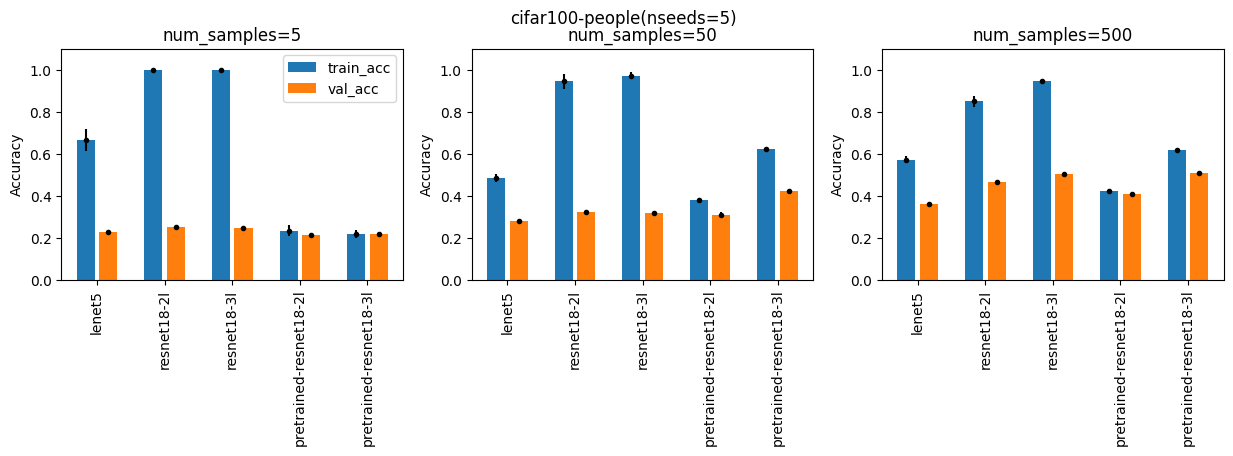

In [9]:
def viz(dataset, arr_ns=[5, 50, 500]):
    
    models = [
        "lenet5",
        "resnet18-2l",
        "resnet18-3l",
        "pretrained-resnet18-2l",
        "pretrained-resnet18-3l",

#         "resnet18-full",
    ]
    
    seeds = list(range(1, 5+1))
    
    ncols = len(arr_ns)
    
    plt.figure(figsize=(ncols * 5, 3))
    plt.suptitle(f"{dataset}(nseeds={len(seeds)})", y=1.01)
    
    ticks = np.arange(len(models)) * 3

    for nix, num_samples in enumerate(arr_ns):
        plt.subplot(1, ncols, nix+1)
        plt.ylim([0, 1.1])
        plt.title(f"num_samples={num_samples}")
        plt.xticks(ticks + 0.5, models, rotation=90)

        plt.ylabel("Accuracy")
        for cix, col in enumerate(["train_acc", "val_acc"]):
            arr_metric = []

            for model in models:
                df = load(dataset, model, num_samples=num_samples, seeds=seeds)
                stat = df[df.epoch==df.epoch.max()][col].values.tolist()

                arr_metric.append(stat)
    
            arr_metric = np.array(arr_metric)
            mean = arr_metric.mean(axis=1)
            
            stderr = arr_metric.std(axis=1) / arr_metric.shape[1] ** 0.5
            plt.bar(ticks + cix,  mean, label=col)
            plt.errorbar(
                ticks + cix,
                mean, 
                yerr=stderr,
                fmt=".",
                color="k"
            )

        
                
        if nix == 0:
            plt.legend()


viz("cifar100-people")